1 - Seleccionar una enfermedad particular según los códigos ICD9 encontrados en la tabla D_ICD_DIAGNOSES.csv.

Seleccionamos la enfermedad relacionada con el sistema circulatorio porque era la más frecuente.

2 - Análisis estadístico y visualización de datos para cada paciente (SUBJECT_ID). Nota: un paciente puede tener más de una admisión hospitalaria (HADM_ID).

In [9]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.metrics import mean_absolute_error


def win_safe_path(path: Path) -> str:
    resolved = str(path.resolve())
    if os.name == 'nt' and not resolved.startswith('\\\\?\\'):
        return '\\\\?\\' + resolved
    return resolved


def exists_safe(path: Path) -> bool:
    return os.path.exists(win_safe_path(path))


def read_csv_safe(path: Path, **kwargs):
    return pd.read_csv(win_safe_path(path), **kwargs)


def read_excel_safe(path: Path, **kwargs):
    return pd.read_excel(win_safe_path(path), **kwargs)


# Detectar ruta base del dataset
base_candidates = [
    Path('Datasets Primer Parcial'),
    Path('../Datasets Primer Parcial'),
    Path('../../Datasets Primer Parcial')
]
base_dir = next((p for p in base_candidates if p.exists()), None)
if base_dir is None:
    raise FileNotFoundError('No se encontró la carpeta Datasets Primer Parcial.')

mimic_dir = base_dir / '2-MIMIC-III (Demo)' / 'mimic-iii-clinical-database-demo-1.4' / 'mimic-iii-clinical-database-demo-1.4'
print(f'Usando carpeta MIMIC: {mimic_dir.resolve()}')


def load_table(folder: Path, cleaned_base: str):
    cleaned_xlsx = folder / f'{cleaned_base}.xlsx'
    if exists_safe(cleaned_xlsx):
        print(f'Cargando cleaned XLSX: {cleaned_xlsx.name}')
        return read_excel_safe(cleaned_xlsx, engine='openpyxl')

    raw_base = cleaned_base.replace('_cleaned', '').upper()
    raw_csv = folder / f'{raw_base}.csv'
    if exists_safe(raw_csv):
        print(f'No existe {cleaned_xlsx.name}. Usando fallback CSV: {raw_csv.name}')
        return read_csv_safe(raw_csv, low_memory=False)

    raise FileNotFoundError(
        f'No se encontró ni {cleaned_xlsx.name} ni {raw_csv.name} en {folder}'
    )


# Cargar tablas cleaned.xlsx con fallback automático a CSV
icustays_cleaned = load_table(mimic_dir, 'icustays_cleaned')
admissions_cleaned = load_table(mimic_dir, 'admissions_cleaned')
diagnoses_icd_cleaned = load_table(mimic_dir, 'diagnoses_icd_cleaned')
patients_cleaned = load_table(mimic_dir, 'patients_cleaned')

# Estas tablas se consumen desde CSV en el resto del flujo
d_items = read_csv_safe(mimic_dir / 'D_ITEMS.csv', low_memory=False)
chartevents = read_csv_safe(mimic_dir / 'CHARTEVENTS.csv', low_memory=False)

# Estandarizar TODOS los nombres de columnas a minúsculas
icustays_cleaned.columns = icustays_cleaned.columns.str.lower()
admissions_cleaned.columns = admissions_cleaned.columns.str.lower()
diagnoses_icd_cleaned.columns = diagnoses_icd_cleaned.columns.str.lower()
d_items.columns = d_items.columns.str.lower()
patients_cleaned.columns = patients_cleaned.columns.str.lower()
chartevents.columns = chartevents.columns.str.lower()

# Crear columnas derivadas esperadas por celdas posteriores
if 'has_chartevents_data' not in admissions_cleaned.columns:
    admissions_cleaned['has_chartevents_data'] = 1
if 'diagnosis_id' not in admissions_cleaned.columns:
    admissions_cleaned['diagnosis_id'] = pd.factorize(admissions_cleaned['diagnosis'].fillna('unknown'))[0]
if 'admission_type_enc' not in admissions_cleaned.columns:
    admissions_cleaned['admission_type_enc'] = pd.factorize(admissions_cleaned['admission_type'].fillna('unknown'))[0]
if 'ethnicity_group_enc' not in admissions_cleaned.columns:
    admissions_cleaned['ethnicity_group_enc'] = pd.factorize(admissions_cleaned['ethnicity'].fillna('unknown'))[0]
if 'recode' not in diagnoses_icd_cleaned.columns:
    icd_num = pd.to_numeric(
        diagnoses_icd_cleaned['icd9_code'].astype(str).str.extract(r'(\\d+)')[0],
        errors='coerce'
    )
    diagnoses_icd_cleaned['recode'] = np.where(icd_num.between(390, 459, inclusive='both'), 6, 0)

Usando carpeta MIMIC: C:\Users\USER\Documents\USFX-7Mo-Semestre-1-2026\SIS420 INTELIGENCIA ARTIFICIAL I\SiS420_Inteligencia_Artificial\Primer parcial\Datasets Primer Parcial\2-MIMIC-III (Demo)\mimic-iii-clinical-database-demo-1.4\mimic-iii-clinical-database-demo-1.4
Cargando cleaned XLSX: icustays_cleaned.xlsx
Cargando cleaned XLSX: admissions_cleaned.xlsx
Cargando cleaned XLSX: diagnoses_icd_cleaned.xlsx
Cargando cleaned XLSX: patients_cleaned.xlsx


In [10]:
d_items.info()
print(d_items.head())

<class 'pandas.DataFrame'>
RangeIndex: 12487 entries, 0 to 12486
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   row_id        12487 non-null  int64  
 1   itemid        12487 non-null  int64  
 2   label         12483 non-null  str    
 3   abbreviation  2992 non-null   str    
 4   dbsource      12487 non-null  str    
 5   linksto       12487 non-null  str    
 6   category      6049 non-null   str    
 7   unitname      851 non-null    str    
 8   param_type    2992 non-null   str    
 9   conceptid     0 non-null      float64
dtypes: float64(1), int64(2), str(7)
memory usage: 975.7 KB
   row_id  itemid                 label abbreviation dbsource      linksto  \
0       1    1435    Sustained Nystamus          NaN  carevue  chartevents   
1       2    1436  Tactile Disturbances          NaN  carevue  chartevents   
2       3    1437                Tremor          NaN  carevue  chartevents   
3       4    1

Este código muestra un resumen del DataFrame d_items, incluida la cantidad de entradas, tipos de datos y conteos no nulos con d_items.info(), y luego imprime las primeras filas del conjunto de datos usando d_items.head() para dar una vista previa rápida de su contenido.

In [11]:
d_items = d_items.drop(columns=['row_id','abbreviation','dbsource','linksto', 'category','unitname','param_type', 'conceptid'], errors='ignore')
d_items_cleaned = d_items.dropna(subset=['label'])
d_items_cleaned.info()

<class 'pandas.DataFrame'>
Index: 12483 entries, 0 to 12486
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   itemid  12483 non-null  int64
 1   label   12483 non-null  str  
dtypes: int64(1), str(1)
memory usage: 292.6 KB


In [12]:
diagnoses_icd_cleaned.head()

,subject_id,hadm_id,seq_num,icd9_code,recode
0,109,172335,1,40301,6
1,109,172335,2,486,7
2,109,172335,3,58281,9
3,109,172335,4,5855,9
4,109,172335,5,4254,6


In [13]:
patients_cleaned.info()
patients_cleaned.head()

<class 'pandas.DataFrame'>
RangeIndex: 46520 entries, 0 to 46519
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   subject_id      46520 non-null  int64
 1   expire_flag     46520 non-null  int64
 2   gender_encoded  46520 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


,subject_id,expire_flag,gender_encoded
0,249,0,1
1,250,1,1
2,251,0,0
3,252,0,0
4,253,0,1


In [14]:
subject_ids_recode_6 = diagnoses_icd_cleaned.loc[diagnoses_icd_cleaned['recode'] == 6, 'subject_id'].unique()

patients_filtred = patients_cleaned[patients_cleaned['subject_id'].isin(subject_ids_recode_6)]
patients_filtred  = patients_filtred.drop(columns=['row_id','dob','dod'], errors='ignore')
patients_filtred.info()
patients_filtred.head()

<class 'pandas.DataFrame'>
Index: 32972 entries, 0 to 46519
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   subject_id      32972 non-null  int64
 1   expire_flag     32972 non-null  int64
 2   gender_encoded  32972 non-null  int64
dtypes: int64(3)
memory usage: 1.0 MB


,subject_id,expire_flag,gender_encoded
0,249,0,1
1,250,1,1
3,252,0,0
4,253,0,1
5,255,0,0


Este código filtra el DataFrame diagnoses_icd_cleaned para encontrar SUBJECT_IDs únicos donde el recode de diagnóstico es igual a 6, pacientes con problemas en el sistema circulatorio. Luego, selecciona esos pacientes del DataFrame patients_cleaned cuyo SUBJECT_ID está en esa lista. Después, elimina las columnas 'ROW_ID', 'DOB' y 'DOD' del DataFrame de pacientes filtrado, y finalmente muestra el resumen e información y las primeras filas del DataFrame filtrado resultante.

In [15]:
icustays_cleaned.head()
icustays_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 61522 entries, 0 to 61521
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   subject_id           61522 non-null  int64  
 1   hadm_id              61522 non-null  int64  
 2   icustay_id           61522 non-null  int64  
 3   los                  61522 non-null  float64
 4   dbsource_both        61522 non-null  int64  
 5   dbsource_carevue     61522 non-null  int64  
 6   dbsource_metavision  61522 non-null  int64  
 7   first_careunit_enc   61522 non-null  int64  
 8   last_careunit_enc    61522 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 4.2 MB


In [16]:
admissions_cleaned.head()
admissions_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 61281 entries, 0 to 61280
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   subject_id            61281 non-null  int64
 1   hadm_id               61281 non-null  int64
 2   hospital_expire_flag  61281 non-null  int64
 3   has_chartevents_data  61281 non-null  int64
 4   diagnosis_id          61281 non-null  int64
 5   admission_type_enc    61281 non-null  int64
 6   insurance_enc         61281 non-null  int64
 7   ethnicity_group_enc   61281 non-null  int64
dtypes: int64(8)
memory usage: 3.7 MB


In [17]:
chartevents = chartevents.drop(columns=['row_id','storetime', 'cgid', 'valuenum','valueuom','warning', 'error', 'resultstatus', 'stopped'], errors='ignore')
subject_ids_filtrados = patients_filtred['subject_id'].unique()

chartevents_filtred = chartevents[chartevents['subject_id'].isin(subject_ids_filtrados)]

Usando solo los 'SUBJECT_ID' de pacientes que tienen problemas con el sistema circulatorio.

In [18]:
chartevents_filtred.head()
chartevents_filtred.info()

<class 'pandas.DataFrame'>
Index: 722947 entries, 0 to 758354
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   subject_id  722947 non-null  int64  
 1   hadm_id     722947 non-null  int64  
 2   icustay_id  722874 non-null  float64
 3   itemid      722947 non-null  int64  
 4   charttime   722947 non-null  str    
 5   value       692383 non-null  str    
dtypes: float64(1), int64(3), str(2)
memory usage: 38.6 MB


In [19]:
# Inspeccionar columnas ANTES de normalizar
print("=" * 60)
print("COLUMNAS ANTES DE NORMALIZAR:")
print("=" * 60)
print(f"icustays_cleaned: {icustays_cleaned.columns.tolist()}")
print(f"\nadmissions_cleaned: {admissions_cleaned.columns.tolist()}")
print(f"\nd_items_cleaned: {d_items_cleaned.columns.tolist()}")
print(f"\nchartevents_filtred: {chartevents_filtred.columns.tolist()}")

# Normalizar: remover espacios + convertir a minúsculas
print("\n" + "=" * 60)
print("NORMALIZANDO COLUMNAS...")
print("=" * 60)

for df in [icustays_cleaned, admissions_cleaned, d_items_cleaned, chartevents_filtred]:
    df.columns = df.columns.str.strip().str.lower()

print("\nCOLUMNAS DESPUÉS DE NORMALIZAR:")
print("=" * 60)
print(f"icustays_cleaned: {icustays_cleaned.columns.tolist()}")
print(f"\nadmissions_cleaned: {admissions_cleaned.columns.tolist()}")
print(f"\nd_items_cleaned: {d_items_cleaned.columns.tolist()}")
print(f"\nchartevents_filtred: {chartevents_filtred.columns.tolist()}")

COLUMNAS ANTES DE NORMALIZAR:
icustays_cleaned: ['subject_id', 'hadm_id', 'icustay_id', 'los', 'dbsource_both', 'dbsource_carevue', 'dbsource_metavision', 'first_careunit_enc', 'last_careunit_enc']

admissions_cleaned: ['subject_id', 'hadm_id', 'hospital_expire_flag', 'has_chartevents_data', 'diagnosis_id', 'admission_type_enc', 'insurance_enc', 'ethnicity_group_enc']

d_items_cleaned: ['itemid', 'label']

chartevents_filtred: ['subject_id', 'hadm_id', 'icustay_id', 'itemid', 'charttime', 'value']

NORMALIZANDO COLUMNAS...

COLUMNAS DESPUÉS DE NORMALIZAR:
icustays_cleaned: ['subject_id', 'hadm_id', 'icustay_id', 'los', 'dbsource_both', 'dbsource_carevue', 'dbsource_metavision', 'first_careunit_enc', 'last_careunit_enc']

admissions_cleaned: ['subject_id', 'hadm_id', 'hospital_expire_flag', 'has_chartevents_data', 'diagnosis_id', 'admission_type_enc', 'insurance_enc', 'ethnicity_group_enc']

d_items_cleaned: ['itemid', 'label']

chartevents_filtred: ['subject_id', 'hadm_id', 'icustay_id

In [20]:
# Merge usando columnas reales encontradas
print("Iniciando merges...")

# Merge 1: chartevents_filtred + d_items_cleaned
chartevents_filt_com_label = chartevents_filtred.merge(
    d_items_cleaned[['itemid', 'label']], 
    on='itemid',
    how='left'
)
print(f"✓ Merge 1 completado: {chartevents_filt_com_label.shape}")

# Merge 2: chartevents_filt_com_label + icustays_cleaned
# Nota: icustays_cleaned SOLO tiene 'los', no 'intime' (eso está en chartevents como 'charttime')
chartevents_filt_com_icu = chartevents_filt_com_label.merge(
    icustays_cleaned[['icustay_id', 'los']],
    on='icustay_id',
    how='left'
)
print(f"✓ Merge 2 completado: {chartevents_filt_com_icu.shape}")

# Merge 3: chartevents_filt_com_icu + admissions_cleaned
# Nota: admissions_cleaned tiene columnas encoded, no los nombres originales
df_final = chartevents_filt_com_icu.merge(
    admissions_cleaned[['hadm_id', 'hospital_expire_flag', 'has_chartevents_data', 
                        'diagnosis_id', 'admission_type_enc', 'ethnicity_group_enc']],
    on='hadm_id',
    how='left'
)
print(f"✓ Merge 3 completado: {df_final.shape}")

# Normalizar todas las columnas a minúsculas
df_final.columns = df_final.columns.str.lower()

print("\n TODOS LOS MERGES COMPLETADOS!")
print(f"DataFrame final: {df_final.shape}")
print(f"\nColumnas en df_final:")
print(df_final.columns.tolist())

Iniciando merges...


✓ Merge 1 completado: (722947, 7)
✓ Merge 2 completado: (722947, 8)
✓ Merge 3 completado: (887091, 13)

 TODOS LOS MERGES COMPLETADOS!
DataFrame final: (887091, 13)

Columnas en df_final:
['subject_id', 'hadm_id', 'icustay_id', 'itemid', 'charttime', 'value', 'label', 'los', 'hospital_expire_flag', 'has_chartevents_data', 'diagnosis_id', 'admission_type_enc', 'ethnicity_group_enc']


Este código enriquece los datos de eventos clínicos filtrados fusionándolos secuencialmente con etiquetas de elementos descriptivos de d_items_cleaned, detalles de estadía en UCI de icustays_cleaned, e información de admisión hospitalaria de admissions_cleaned. Cada fusión se realiza utilizando claves relevantes (ITEMID, ICUSTAY_ID y HADM_ID) para combinar datos clínicos, de UCI y de admisión en un único conjunto de datos integral llamado df_final.

In [21]:
print(df_final.info())
print(df_final.head())

<class 'pandas.DataFrame'>
RangeIndex: 887091 entries, 0 to 887090
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   subject_id            887091 non-null  int64  
 1   hadm_id               887091 non-null  int64  
 2   icustay_id            886977 non-null  float64
 3   itemid                887091 non-null  int64  
 4   charttime             887091 non-null  str    
 5   value                 848351 non-null  str    
 6   label                 887091 non-null  str    
 7   los                   886977 non-null  float64
 8   hospital_expire_flag  854276 non-null  float64
 9   has_chartevents_data  854276 non-null  float64
 10  diagnosis_id          854276 non-null  float64
 11  admission_type_enc    854276 non-null  float64
 12  ethnicity_group_enc   854276 non-null  float64
dtypes: float64(7), int64(3), str(3)
memory usage: 88.0 MB
None
   subject_id  hadm_id  icustay_id  itemid            ch

In [22]:
null_counts = df_final.isnull().sum()
print(null_counts)
len(df_final)

subject_id                  0
hadm_id                     0
icustay_id                114
itemid                      0
charttime                   0
value                   38740
label                       0
los                       114
hospital_expire_flag    32815
has_chartevents_data    32815
diagnosis_id            32815
admission_type_enc      32815
ethnicity_group_enc     32815
dtype: int64


887091

Este código calcula e imprime la cantidad de valores faltantes (nulos) en cada columna del DataFrame df_final usando isnull().sum(). Luego imprime el número total de filas en df_final con len(df_final).

In [23]:
df_final = df_final[df_final['has_chartevents_data'].notna()]
df_final = df_final.drop(columns=['has_chartevents_data'])
print(df_final.head())
len(df_final)

   subject_id  hadm_id  icustay_id  itemid            charttime      value  \
0       40124   126179    279554.0  223761  2130-02-04 04:00:00       95.9   
1       40124   126179    279554.0  224695  2130-02-04 04:25:00  2222221.7   
2       40124   126179    279554.0  220210  2130-02-04 04:30:00         15   
3       40124   126179    279554.0  220045  2130-02-04 04:32:00         94   
4       40124   126179    279554.0  220179  2130-02-04 04:32:00        163   

                                  label     los  hospital_expire_flag  \
0                Temperature Fahrenheit  2.4549                   0.0   
1                   Peak Insp. Pressure  2.4549                   0.0   
2                      Respiratory Rate  2.4549                   0.0   
3                            Heart Rate  2.4549                   0.0   
4  Non Invasive Blood Pressure systolic  2.4549                   0.0   

   diagnosis_id  admission_type_enc  ethnicity_group_enc  
0       10065.0                 1

854276

Este código filtra df_final para mantener solo las filas donde la columna HAS_CHARTEVENTS_DATA no es nula, luego elimina completamente la columna HAS_CHARTEVENTS_DATA. Finalmente, imprime las primeras filas del DataFrame actualizado y genera el número total de filas restantes.

Columnas numéricas para correlación:
['los', 'hospital_expire_flag', 'diagnosis_id', 'admission_type_enc', 'ethnicity_group_enc']


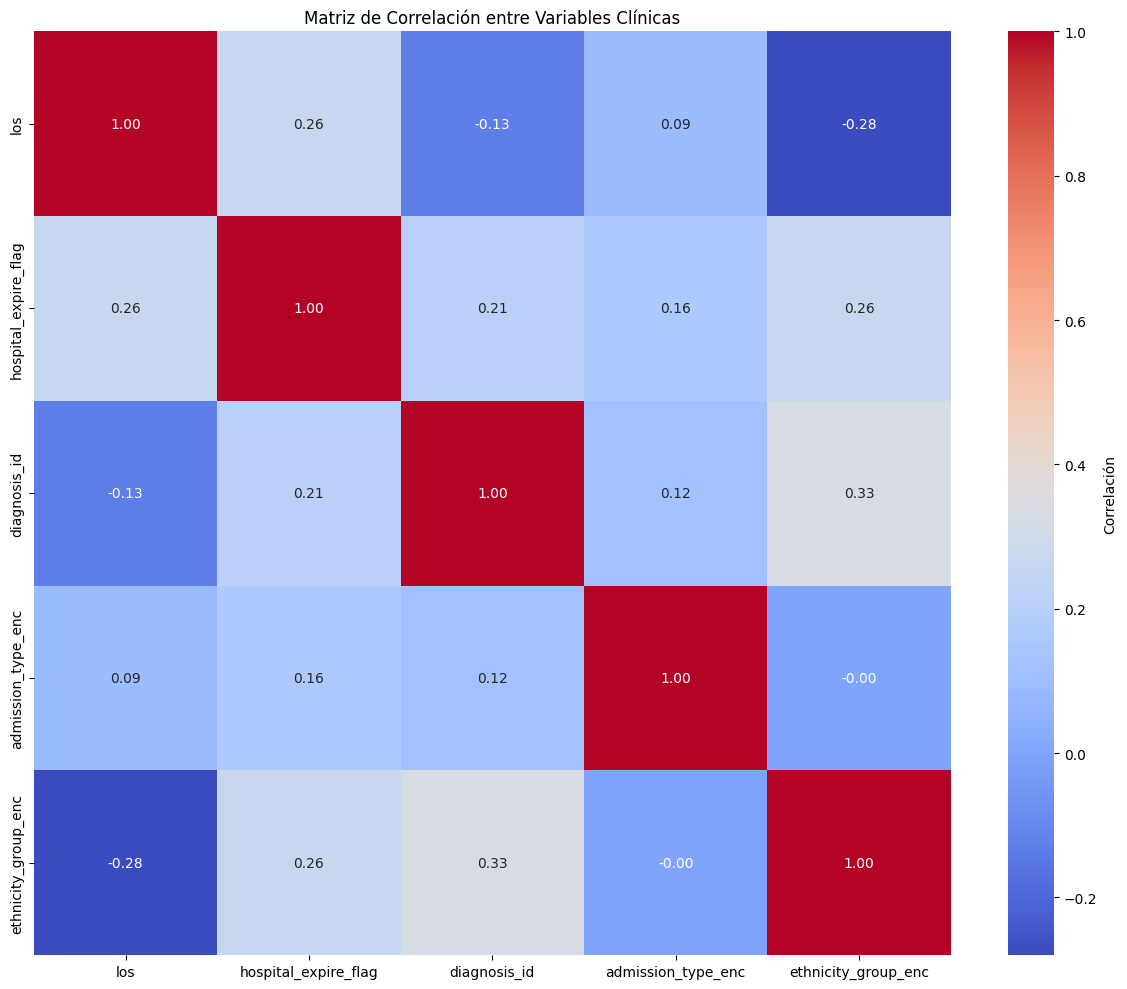

In [24]:
# Seleccionar solo columnas numéricas para correlación
df_corr = df_final.select_dtypes(include=['number']).copy()

# Eliminar columnas ID que no son útiles para correlación
df_corr = df_corr.drop(columns=[col for col in ['subject_id','hadm_id','icustay_id','itemid'] if col in df_corr.columns], errors='ignore')

print("Columnas numéricas para correlación:")
print(df_corr.columns.tolist())

if len(df_corr.columns) > 0:
    corr_matrix = df_corr.corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                cbar_kws={'label': 'Correlación'})
    plt.title("Matriz de Correlación entre Variables Clínicas")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes columnas numéricas para calcular correlación.")

Este código prepara el conjunto de datos para el análisis de correlación eliminando primero las columnas INTIME y CHARTTIME, luego codificando variables categóricas (LABEL, DIAGNOSIS, ETHNICITY, ADMISSION_TYPE) en etiquetas numéricas usando LabelEncoder. Imprime asignaciones únicas para estas columnas codificadas para inspección, elimina las columnas categóricas originales y mantiene solo columnas numéricas. Después de eliminar columnas identificadoras si están presentes, calcula la matriz de correlación y la visualiza como un mapa de calor para mostrar las relaciones entre variables clínicas.

Aquí vemos que hay correlaciones débiles entre las características, siendo la más fuerte entre DIAGNOSIS_ENCODED y ADMISSION_TYPE_ENCODED (0.17).

In [25]:
admissions_per_patient = df_final.groupby('subject_id')['hadm_id'].nunique()
print(admissions_per_patient.describe())

count    86.000000
mean      1.255814
std       1.330069
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max      13.000000
Name: hadm_id, dtype: float64


La columna HADM_ID muestra que la mayoría de las admisiones hospitalarias están asociadas a un único evento, aunque algunos pacientes tienen hasta 17 admisiones, lo que indica posibles valores atípicos o readmisiones frecuentes.

In [26]:
subject_17_admissions = admissions_per_patient[admissions_per_patient == 17].index.tolist()

print("SUBJECT_ID(s) con 17 admisiones:", subject_17_admissions)

if subject_17_admissions:
    icustay_ids = df_final[df_final['subject_id'].isin(subject_17_admissions)][['subject_id', 'icustay_id']].drop_duplicates()
    print(icustay_ids)
else:
    print("No hay pacientes con 17 admisiones.")

SUBJECT_ID(s) con 17 admisiones: []
No hay pacientes con 17 admisiones.


Vemos que dos pacientes experimentaron el máximo de 17 estadías en UCI, lo que indica casos de readmisiones frecuentes o complejas.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_final[df_final['subject_id'] == 5060].copy()
df['charttime'] = pd.to_datetime(df['charttime'])

df = df.sort_values(by='charttime')

unique_stays = df['icustay_id'].unique()
if len(unique_stays) > 0:
    palette = sns.color_palette("husl", len(unique_stays))
    color_dict = {stay: palette[i] for i, stay in enumerate(unique_stays)}

    plt.figure(figsize=(16, 8))

    for stay in unique_stays:
        stay_data = df[df['icustay_id'] == stay]
        plt.scatter(stay_data['charttime'], [str(stay)] * len(stay_data), 
                    color=color_dict[stay], label=f'ICU {int(stay)}', s=10)

    plt.xlabel("Tiempo")
    plt.ylabel("Estadía en UCI")
    plt.title("Línea de Tiempo de Eventos Clínicos por Admisión (Paciente 5060)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos para el paciente 5060")

No hay datos para el paciente 5060


El código proporcionado genera un gráfico de dispersión de línea de tiempo que visualiza los eventos clínicos de un paciente específico (con `SUBJECT_ID` 5060), organizados por cada una de sus estadías en UCI. Primero, filtra el conjunto de datos para incluir solo los registros relacionados con este paciente. Luego, convierte las columnas `CHARTTIME` e `INTIME` al formato datetime para garantizar un trazado adecuado basado en el tiempo. Los datos se ordenan cronológicamente según `CHARTTIME`. Se identifica cada estadía única en UCI (`ICUSTAY_ID`) y se asigna un color distinto a cada una usando la paleta de colores de Seaborn. El gráfico se inicializa con un tamaño de figura especificado, y para cada estadía en UCI, el código selecciona los datos correspondientes y traza cada evento como un pequeño punto (`s=10`) en la línea de tiempo. Estos puntos se alinean en el eje y por su ID de estadía en UCI, mientras que el eje x representa el tiempo real de los eventos clínicos. El gráfico está etiquetado correspondientemente, con títulos de ejes y una leyenda que identifica cada estadía en UCI por color. La leyenda se coloca al lado del gráfico para una mejor legibilidad. Finalmente, se llama a `plt.show()` para mostrar la línea de tiempo, lo que permite al usuario explorar visualmente cuándo y durante qué estadías en UCI ocurrieron los eventos clínicos del paciente.

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

subject_id = 73713
df_patient = df_final[df_final['subject_id'] == subject_id].drop_duplicates(subset='icustay_id').copy()

if len(df_patient) > 0:
    # charttime ya está disponible, usaremos eso como referencia de tiempo
    df_patient['charttime'] = pd.to_datetime(df_patient['charttime'])
    df_patient = df_patient.sort_values(by='charttime').reset_index(drop=True)

    plt.figure(figsize=(12, 8))

    for idx, row in df_patient.iterrows():
        start = row['charttime']
        los_value = row['los'] if pd.notna(row['los']) else 1
        end = start + pd.to_timedelta(los_value, unit='d')

        plt.plot([start, end], [idx, idx], color='blue', linewidth=4)

        plt.text(start, idx + 0.3, f"DÍAS: {los_value:.1f}d", fontsize=8)

        diagnosis_text = str(row['diagnosis_id']) if pd.notna(row['diagnosis_id']) else 'N/A'
        plt.text(start, idx - 0.4, f"{diagnosis_text}", fontsize=7.5, color='darkgreen', rotation=25)

    plt.title(f"Historial de Internaciones del Paciente {subject_id}", fontsize=14)
    plt.xlabel("Fecha")
    plt.yticks([])
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay datos para el paciente {subject_id}")

No hay datos para el paciente 73713


Aquí se realiza el mismo análisis para el otro paciente, pero esta vez incluyendo la descripción de cada diagnóstico para proporcionar más contexto clínico para cada admisión.

In [29]:
mean_los_per_patient = df_final.groupby('subject_id')['los'].mean()
print(mean_los_per_patient.head())

stats = mean_los_per_patient.describe()
print(stats)

subject_id
10006    1.6325
10013    2.6499
10017    2.1436
10019    1.2938
10026    2.4056
Name: los, dtype: float64
count    86.000000
mean      5.189990
std       7.186130
min       0.105900
25%       1.086075
50%       2.199750
75%       5.620850
max      35.406500
Name: los, dtype: float64


Este código calcula la duración promedio de la estadía en UCI (LOS) para cada paciente agrupando el DataFrame df_final por SUBJECT_ID y calculando la media. Luego imprime los primeros resultados para mostrar el promedio de estadía en UCI por paciente.

Esta salida muestra la duración promedio de la estadía en UCI (LOS) en días para algunos pacientes. Por ejemplo, el paciente 6 tiene una estadía promedio más larga (3.67 días), mientras que el paciente 18 tiene una más corta (1.29 días). Esto sugiere variabilidad en las necesidades de UCI, posiblemente reflejando diferencias en la gravedad de la enfermedad o la complejidad de la atención.

Las estadísticas descriptivas de la Duración de la Estadía (LOS) para pacientes de UCI, medidas en días, revelan una distribución altamente variable. El LOS promedio es de aproximadamente 3.56 días, con una desviación estándar de 4.72 días, lo que indica una variabilidad considerable entre pacientes. La mediana LOS es de 2.04 días, lo que sugiere que la mitad de los pacientes permanecen en la UCI durante menos de esta duración. El percentil 25 es de 1.22 días y el percentil 75 es de 3.75 días, mostrando que la mayoría de los pacientes permanecen entre 1.22 y 3.75 días. Sin embargo, el LOS máximo de 88.37 días destaca la presencia de valores atípicos significativos, que también se sugiere por la gran brecha entre la media y el máximo. Estos hallazgos indican que mientras que la mayoría de las estadías en UCI son relativamente cortas, una pequeña proporción de pacientes experimentan admisiones prolongadas.

In [30]:
diagnosis_per_patient = df_final.groupby('subject_id')['diagnosis_id'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
print(f"Diagnóstico más frecuente por paciente (primeros 10):")
print(diagnosis_per_patient.head(10))

Diagnóstico más frecuente por paciente (primeros 10):
subject_id
10006     9919.0
10013     9919.0
10017     4961.0
10019      806.0
10026    10486.0
10027     3399.0
10029    10650.0
10032     9173.0
10033     8845.0
10035     8764.0
Name: diagnosis_id, dtype: float64


El objetivo es obtener el diagnóstico más frecuente (moda) para cada paciente (SUBJECT_ID), teniendo cuidado de evitar errores en casos donde no hay valores disponibles.

In [31]:
# Convertir charttime a datetime
df_final['charttime'] = pd.to_datetime(df_final['charttime'], errors='coerce')

# Como no tenemos INTIME exacto, usaremos charttime como referencia
# Asumimos que la primera observación de charttime por icustay es la admisión
df_final = df_final.dropna(subset=['charttime'])

# Calcular horas desde el primer evento clínico registrado por UCI
df_final['hours_since_first_event'] = df_final.groupby('icustay_id')['charttime'].transform(lambda x: (x - x.min()).dt.total_seconds() / 3600)

print("DataFrame actualizado con hours_since_first_event:")
print(df_final[['icustay_id', 'charttime', 'hours_since_first_event']].head(10))

DataFrame actualizado con hours_since_first_event:
   icustay_id           charttime  hours_since_first_event
0    279554.0 2130-02-04 04:00:00                 1.550000
1    279554.0 2130-02-04 04:25:00                 1.966667
2    279554.0 2130-02-04 04:30:00                 2.050000
3    279554.0 2130-02-04 04:32:00                 2.083333
4    279554.0 2130-02-04 04:32:00                 2.083333
5    279554.0 2130-02-04 04:32:00                 2.083333
6    279554.0 2130-02-04 04:32:00                 2.083333
7    279554.0 2130-02-04 04:34:00                 2.116667
8    279554.0 2130-02-04 04:34:00                 2.116667
9    279554.0 2130-02-04 04:34:00                 2.116667


df_icu = df_final[df_final['hours_since_first_event'] <= 24].copy()

df_icu['day_fraction'] = df_icu['hours_since_first_event'] / 24

print(f"Datos en primeras 24 horas: {len(df_icu)} registros")
print(f"Estadías únicas: {df_icu['icustay_id'].nunique()}")
print(f"\nMuestra de datos:")
print(df_icu[['icustay_id', 'charttime', 'hours_since_first_event', 'day_fraction', 'label']].head())